# SF Police Incident Rate Modelling
## Bayesian Poisson Point Process — DTU Model-Based ML Spring 2026

---

### Motivation

Every row in our dataset is a single incident with an exact timestamp — a **point in time and space**. This makes it a natural **point process** problem. We model hourly incident counts as Poisson-distributed and ask increasingly refined questions:

| Model | Question | Covariates |
|---|---|---|
| **M1** | Is the rate constant? | None |
| **M2** | Does the rate vary by time of day? | Hour of day, day of week |
| **M3** | Does the rate differ by district? | + Police district |
| **M4** | Can districts share statistical strength? | Hierarchical prior over districts |

All models are trained with **SVI** (`AutoDiagonalNormal` guide). We compare VI to **MCMC (NUTS)** on M1 to validate the approximation.

## 1. Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS, Predictive
from pyro.optim import ClippedAdam

torch.manual_seed(42); pyro.set_rng_seed(42); np.random.seed(42)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print(f"Pyro {pyro.__version__} | PyTorch {torch.__version__}")

Pyro 1.9.1 | PyTorch 2.8.0


## 2. Data Loading & Preprocessing

We aggregate the processed incident data to **hourly counts**. Two views:
- **SF-wide**: total per hour — used for M1 and M2.
- **Per-district**: per hour per police district — used for M3 and M4.

**Train:** 2022–2023  &nbsp;|&nbsp;  **Test:** 2024

In [2]:
df = pd.read_csv('../../data/processed/incidents_2018_2025.csv', low_memory=False)
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df['hour_bin']    = df['Incident Datetime'].dt.floor('h')
df['hour_of_day'] = df['Incident Datetime'].dt.hour
df['day_of_week'] = df['Incident Datetime'].dt.dayofweek

df_train = df[df['Incident Datetime'].dt.year.isin([2018, 2019, 2020, 2021, 2022, 2023])].copy()
df_test  = df[df['Incident Datetime'].dt.year.isin([2024, 2025])].copy()
print(f"Train: {len(df_train):,} incidents | Test: {len(df_test):,} incidents")

Train: 794,604 incidents | Test: 205,045 incidents


In [3]:
def make_hourly_sfwide(subset, t0, t1):
    c = subset.groupby('hour_bin').size().reset_index(name='count')
    idx = pd.date_range(t0, t1, freq='h')[:-1]
    c = c.set_index('hour_bin').reindex(idx, fill_value=0).reset_index()
    c.columns = ['hour_bin','count']
    c['hour_of_day'] = c['hour_bin'].dt.hour
    c['day_of_week']  = c['hour_bin'].dt.dayofweek
    return c

def make_hourly_district(subset, t0, t1, districts):
    c = subset.groupby(['hour_bin','Police District']).size().reset_index(name='count')
    idx = pd.MultiIndex.from_product(
        [pd.date_range(t0, t1, freq='h')[:-1], districts],
        names=['hour_bin','Police District'])
    c = c.set_index(['hour_bin','Police District']).reindex(idx, fill_value=0).reset_index()
    c['hour_of_day'] = c['hour_bin'].dt.hour
    c['day_of_week']  = c['hour_bin'].dt.dayofweek
    return c

districts    = sorted(df['Police District'].dropna().unique())
district_map = {d: i for i, d in enumerate(districts)}
N_DISTRICTS  = len(districts)

train_sf   = make_hourly_sfwide(df_train, '2022-01-01', '2024-01-01')
test_sf    = make_hourly_sfwide(df_test,  '2024-01-01', '2025-01-01')
train_dist = make_hourly_district(df_train, '2022-01-01', '2024-01-01', districts)
test_dist  = make_hourly_district(df_test,  '2024-01-01', '2025-01-01', districts)
train_dist['district_id'] = train_dist['Police District'].map(district_map)
test_dist['district_id']  = test_dist['Police District'].map(district_map)

print(f"SF-wide  train: {len(train_sf):,}  test: {len(test_sf):,}")
print(f"District train: {len(train_dist):,}  test: {len(test_dist):,}")
print(f"Districts ({N_DISTRICTS}): {districts}")

SF-wide  train: 17,520  test: 8,784
District train: 192,720  test: 96,624
Districts (11): ['Bayview', 'Central', 'Ingleside', 'Mission', 'Northern', 'Out of SF', 'Park', 'Richmond', 'Southern', 'Taraval', 'Tenderloin']


In [4]:
# ── Tensors ────────────────────────────────────────────────────────────────────
counts_tr_sf = torch.tensor(train_sf['count'].values,       dtype=torch.float32)
hour_tr_sf   = torch.tensor(train_sf['hour_of_day'].values, dtype=torch.long)
dow_tr_sf    = torch.tensor(train_sf['day_of_week'].values, dtype=torch.long)

counts_te_sf = torch.tensor(test_sf['count'].values,        dtype=torch.float32)
hour_te_sf   = torch.tensor(test_sf['hour_of_day'].values,  dtype=torch.long)
dow_te_sf    = torch.tensor(test_sf['day_of_week'].values,  dtype=torch.long)

counts_tr_d  = torch.tensor(train_dist['count'].values,         dtype=torch.float32)
hour_tr_d    = torch.tensor(train_dist['hour_of_day'].values,   dtype=torch.long)
dow_tr_d     = torch.tensor(train_dist['day_of_week'].values,   dtype=torch.long)
distid_tr_d  = torch.tensor(train_dist['district_id'].values,   dtype=torch.long)

counts_te_d  = torch.tensor(test_dist['count'].values,          dtype=torch.float32)
hour_te_d    = torch.tensor(test_dist['hour_of_day'].values,    dtype=torch.long)
dow_te_d     = torch.tensor(test_dist['day_of_week'].values,    dtype=torch.long)
distid_te_d  = torch.tensor(test_dist['district_id'].values,    dtype=torch.long)

print(f"Mean hourly count (SF-wide):      {counts_tr_sf.mean():.2f}")
print(f"Mean hourly count (per district): {counts_tr_d.mean():.2f}")

Mean hourly count (SF-wide):      15.07
Mean hourly count (per district): 1.37


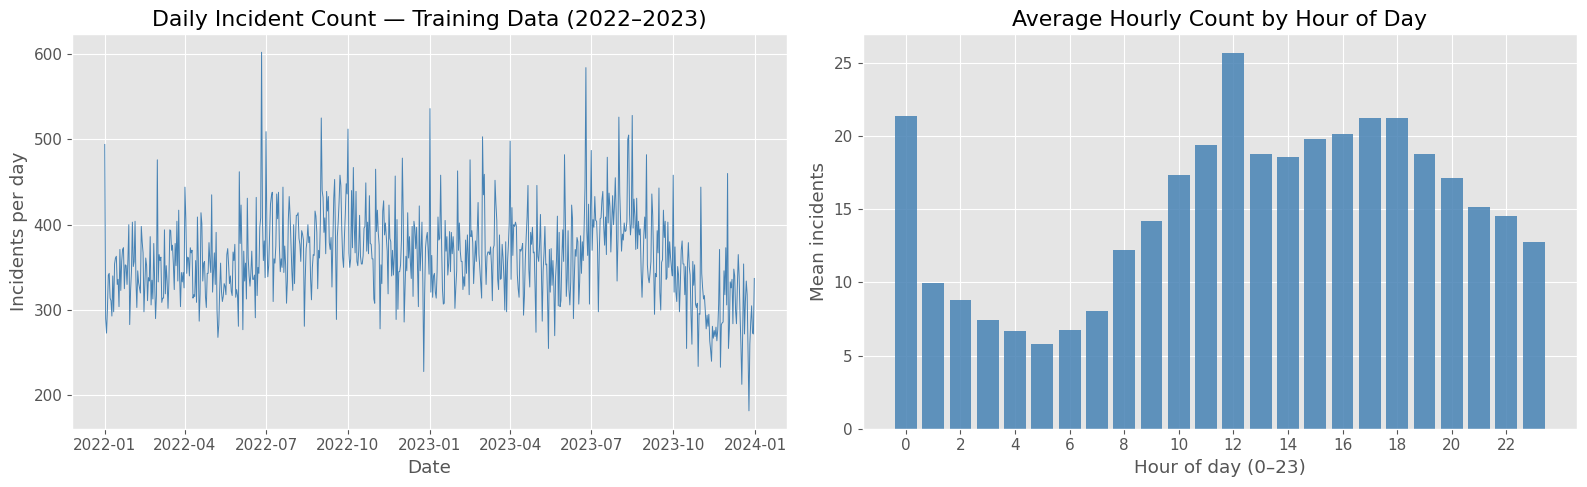

In [5]:
daily = train_sf.copy()
daily['date'] = daily['hour_bin'].dt.date
daily_sum = daily.groupby('date')['count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(pd.to_datetime(daily_sum.index), daily_sum.values, lw=0.7, color='steelblue')
axes[0].set_title('Daily Incident Count — Training Data (2022–2023)')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Incidents per day')

hmean = train_sf.groupby('hour_of_day')['count'].mean()
axes[1].bar(hmean.index, hmean.values, color='steelblue', alpha=0.85)
axes[1].set_title('Average Hourly Count by Hour of Day')
axes[1].set_xlabel('Hour of day (0–23)'); axes[1].set_ylabel('Mean incidents')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 3. Shared Helpers

In [6]:
# ── PGM drawing ────────────────────────────────────────────────────────────────
def draw_pgm(fig_ax, nodes, edges, plates=None):
    r = 0.4
    for name, p in nodes.items():
        fc = '#dddddd' if p.get('obs') else 'white'
        fig_ax.add_patch(plt.Circle((p['x'], p['y']), r, fc=fc, ec='black', lw=2, zorder=3))
        fig_ax.text(p['x'], p['y'], p.get('label', name),
                    ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    for (a, b) in edges:
        na, nb = nodes[a], nodes[b]
        dx, dy = nb['x']-na['x'], nb['y']-na['y']
        d = (dx**2+dy**2)**0.5
        fig_ax.annotate('',
                    xy=(nb['x']-r*dx/d, nb['y']-r*dy/d),
                    xytext=(na['x']+r*dx/d, na['y']+r*dy/d),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=2)
    if plates:
        for pl in plates:
            fig_ax.add_patch(plt.Rectangle((pl['x'],pl['y']),pl['w'],pl['h'],
                                        fill=False, ec='gray', lw=1.5, ls='--', zorder=1))
            fig_ax.text(pl['x']+pl['w']-0.1, pl['y']+0.15, pl.get('label',''),
                        ha='right', va='bottom', fontsize=9, color='gray')
    fig_ax.set_xlim(0,10); fig_ax.set_ylim(0,8)
    fig_ax.set_aspect('equal'); fig_ax.axis('off')

# ── SVI runner ──────────────────────────────────────────────────────────────────
def run_svi(model, args, n_steps=2000, lr=0.01, seed=42):
    pyro.set_rng_seed(seed)
    guide  = AutoDiagonalNormal(model)
    guide._pyro_name = "guide_" + model.__name__  # unique param store key per model
    svi    = SVI(model, guide, ClippedAdam({'lr': lr}), loss=Trace_ELBO())
    losses = []
    for step in range(n_steps):
        loss = svi.step(*args)
        losses.append(loss)
        if step % 500 == 0:
            print(f"  step {step:4d}   ELBO = {-loss:,.0f}")
    return guide, losses

# ── Metrics ─────────────────────────────────────────────────────────────────────
def metrics(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    return mae, rmse

print("Helpers ready.")

Helpers ready.


## 4. Model 1 — Homogeneous Poisson Process (Baseline)

The simplest possible model: crime arrives at a **constant rate** $\lambda$ everywhere, all the time.

### Generative Process

$$\lambda \sim \text{Gamma}(2.0,\; 0.1) \qquad \text{(mean = 20 incidents/hour)}$$
$$y_t \mid \lambda \sim \text{Poisson}(\lambda) \qquad t = 1,\ldots,T$$

The Gamma prior is conjugate to the Poisson likelihood. This model cannot capture any temporal or spatial variation — any model that beats it is learning real structure in the data.

Predicting the number of crime incidents per hour for any given hour in San Fransisco

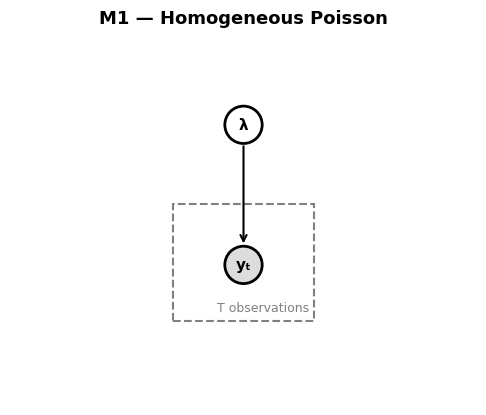

In [7]:
fig, fig_ax = plt.subplots(figsize=(5, 5))
draw_pgm(fig_ax,
    nodes={'lam': {'x':5,'y':6, 'label':'λ',  'obs':False},
           'y':   {'x':5,'y':3, 'label':'yₜ', 'obs':True}},
    edges=[('lam','y')],
    plates=[{'x':3.5,'y':1.8,'w':3,'h':2.5,'label':'T observations'}])
fig_ax.set_title('M1 — Homogeneous Poisson', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
def model_1(counts=None, N=None):
    lam = pyro.sample("lambda", dist.Gamma(torch.tensor(2.0), torch.tensor(0.1)))
    N_obs = len(counts) if counts is not None else N
    with pyro.plate("data", N_obs):
        pyro.sample("y", dist.Poisson(lam), obs=counts)

print("Model 1 defined.")

Model 1 defined.


In [9]:
pyro.clear_param_store()  # clear once before all model training
print("Training M1...")
guide_1, losses_1 = run_svi(model_1, (counts_tr_sf,), n_steps=2000, lr=0.01)

Training M1...
  step    0   ELBO = -97,237
  step  500   ELBO = -77,465
  step 1000   ELBO = -77,465
  step 1500   ELBO = -77,465


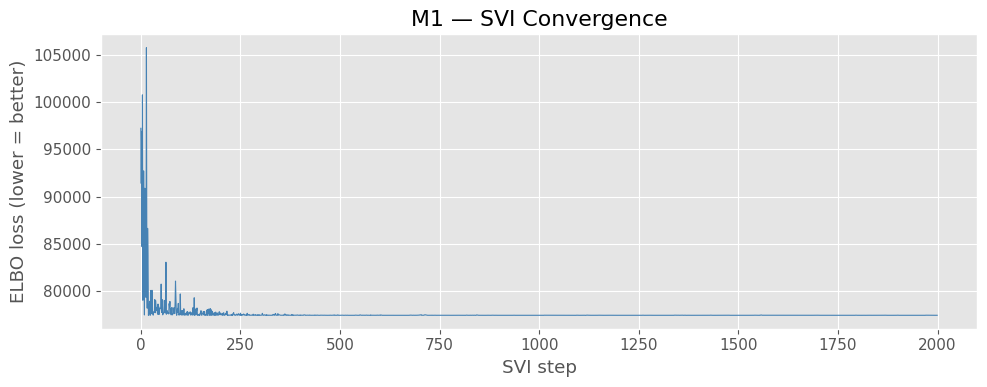

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_1, lw=0.8, color='steelblue')
ax.set_xlabel('SVI step'); ax.set_ylabel('ELBO loss (lower = better)')
ax.set_title('M1 — SVI Convergence')
plt.tight_layout(); plt.show()

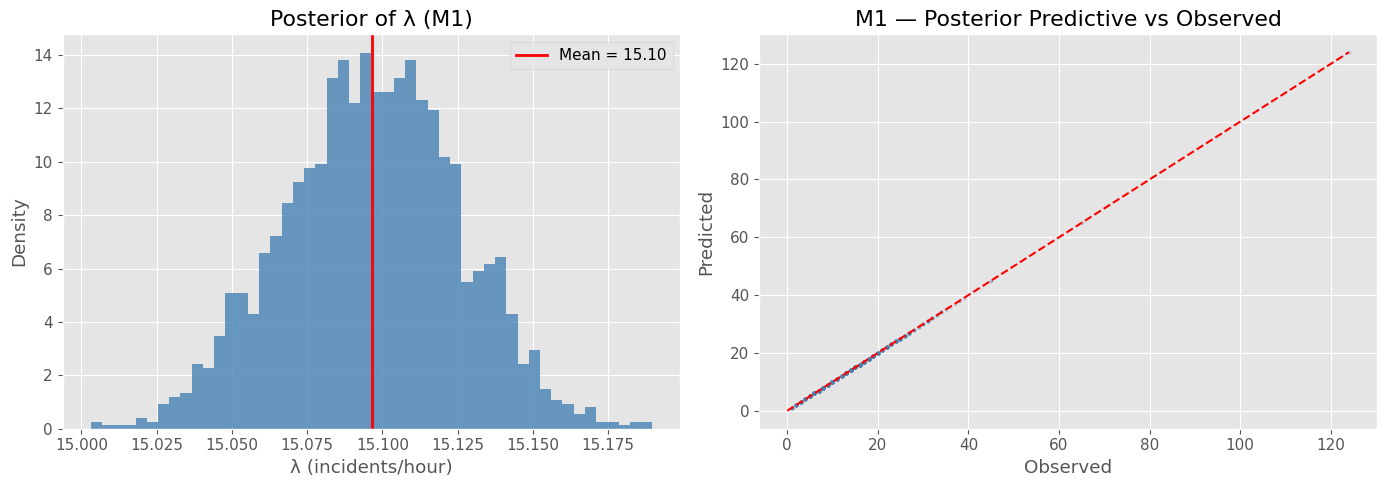

M1 Test → MAE: 6.021   RMSE: 7.428


In [11]:
samp_1 = Predictive(model_1, guide=guide_1, num_samples=2000,
                   return_sites=['lambda'])(counts_tr_sf)
lam_vi = samp_1['lambda'].squeeze().detach().numpy()

# Posterior predictive on train (sample y, not just lambda)
y_pp_1 = Predictive(model_1, guide=guide_1, num_samples=300,
                    return_sites=['y'])(counts_tr_sf)['y'].float().mean(0).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lam_vi, bins=50, color='steelblue', alpha=0.8, density=True)
axes[0].axvline(lam_vi.mean(), color='red', lw=2, label=f'Mean = {lam_vi.mean():.2f}')
axes[0].set_xlabel('λ (incidents/hour)'); axes[0].set_ylabel('Density')
axes[0].set_title('Posterior of λ (M1)'); axes[0].legend()

axes[1].scatter(counts_tr_sf.numpy()[:1000], y_pp_1[:1000], alpha=0.2, s=5, color='steelblue')
lim = max(counts_tr_sf.max().item(), y_pp_1.max())
axes[1].plot([0,lim],[0,lim],'r--',lw=1.5)
axes[1].set_xlabel('Observed'); axes[1].set_ylabel('Predicted')
axes[1].set_title('M1 — Posterior Predictive vs Observed')
plt.tight_layout(); plt.show()

y_pred_te_1 = Predictive(model_1, guide=guide_1, num_samples=200,
                         return_sites=['y'])(N=len(counts_te_sf))['y'].float().mean(0).detach().numpy()
mae1, rmse1 = metrics(counts_te_sf.numpy(), y_pred_te_1)
print(f"M1 Test → MAE: {mae1:.3f}   RMSE: {rmse1:.3f}")

## 5. Model 2 — Inhomogeneous Poisson Process (Time of Day)

We let $\lambda(t)$ vary by **hour of day** and **day of week** using a log-linear intensity. This is the "time-of-day or not" comparison model.

### Generative Process

$$\alpha \sim \mathcal{N}(0,2)$$
$$\beta^{\text{hour}}_h \sim \mathcal{N}(0,1), \quad h=0,\ldots,23$$
$$\beta^{\text{dow}}_d \sim \mathcal{N}(0,1), \quad d=0,\ldots,6$$
$$\log\lambda_t = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)}$$
$$y_t \mid \lambda_t \sim \text{Poisson}(\exp(\log\lambda_t))$$

The log link ensures $\lambda_t > 0$. Each hour-of-day gets its own coefficient so the model can learn any intra-day shape without assuming periodicity.

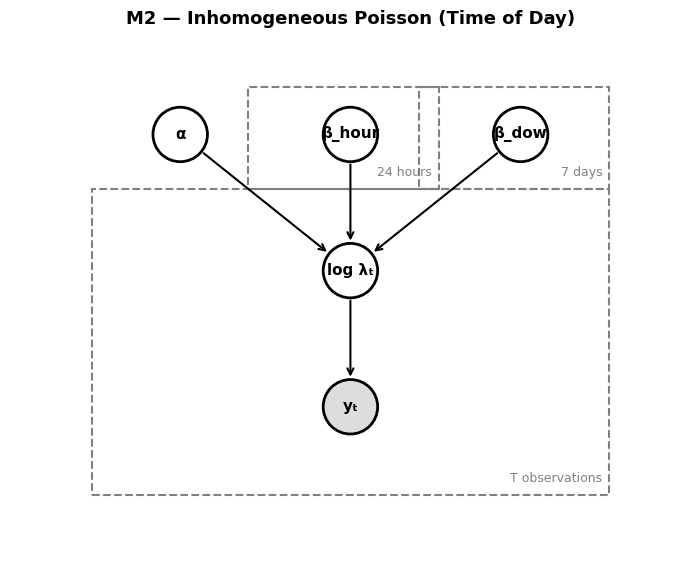

In [12]:
fig, fig_ax = plt.subplots(figsize=(9, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':2.5,'y':6.5, 'label':'α',        'obs':False},
           'b_hour':  {'x':5.0,'y':6.5, 'label':'β_hour',   'obs':False},
           'b_dow':   {'x':7.5,'y':6.5, 'label':'β_dow',    'obs':False},
           'log_lam': {'x':5.0,'y':4.5, 'label':'log λₜ',   'obs':False},
           'y':       {'x':5.0,'y':2.5, 'label':'yₜ',       'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),('log_lam','y')],
    plates=[{'x':1.2,'y':1.2,'w':7.6,'h':4.5,'label':'T observations'},
            {'x':3.5,'y':5.7,'w':2.8,'h':1.5,'label':'24 hours'},
            {'x':6.0,'y':5.7,'w':2.8,'h':1.5,'label':'7 days'}])
fig_ax.set_title('M2 — Inhomogeneous Poisson (Time of Day)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
def model_2(hour_idx, dow_idx, counts=None):
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 2 defined.")

Model 2 defined.


In [14]:
print("Training M2...")
guide_2, losses_2 = run_svi(model_2, (hour_tr_sf, dow_tr_sf, counts_tr_sf), n_steps=2000, lr=0.01)

Training M2...
  step    0   ELBO = -517,257
  step  500   ELBO = -57,669
  step 1000   ELBO = -57,600
  step 1500   ELBO = -57,599


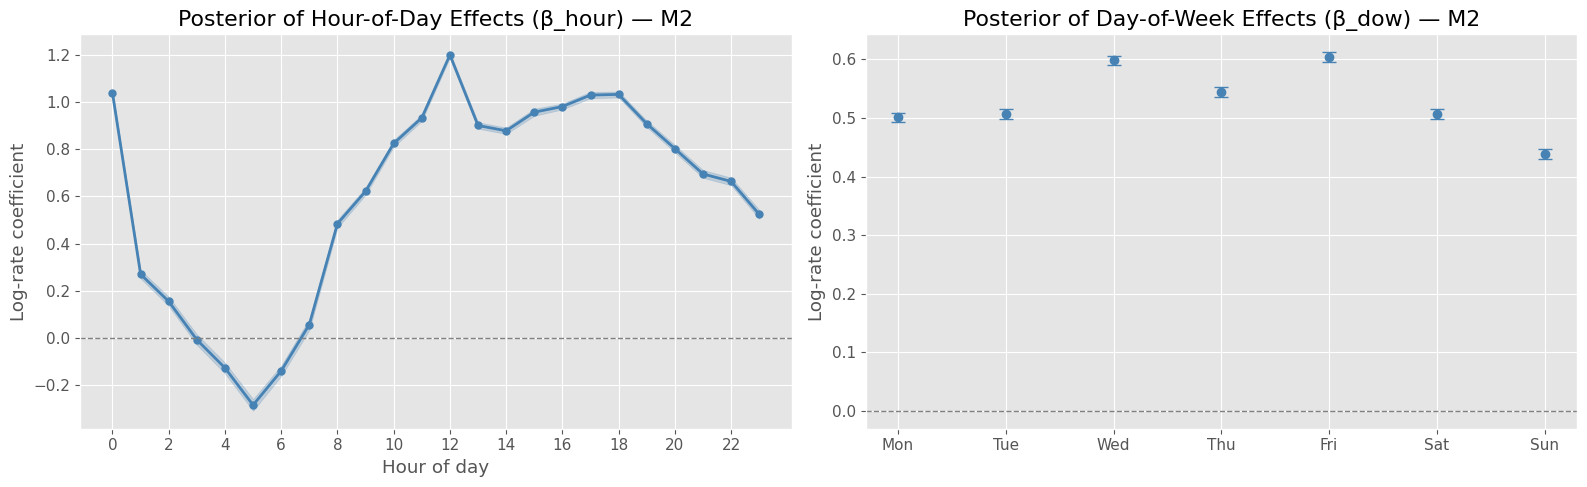

M2 Test → MAE: 4.743   RMSE: 6.025


In [15]:
samp_2 = Predictive(model_2, guide=guide_2, num_samples=2000,
                   return_sites=['b_hour','b_dow'])(hour_tr_sf, dow_tr_sf, counts_tr_sf)

bh = samp_2['b_hour'].squeeze()
bd = samp_2['b_dow'].squeeze()
bh_mean = bh.mean(0).detach().numpy()
bh_lo   = bh.quantile(0.05, dim=0).detach().numpy()
bh_hi   = bh.quantile(0.95, dim=0).detach().numpy()
bd_mean = bd.mean(0).detach().numpy()
bd_lo   = bd.quantile(0.05, dim=0).detach().numpy()
bd_hi   = bd.quantile(0.95, dim=0).detach().numpy()
DOW = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(24), bh_mean, 'o-', color='steelblue', lw=2, ms=5)
axes[0].fill_between(range(24), bh_lo, bh_hi, alpha=0.25, color='steelblue')
axes[0].axhline(0, color='gray', ls='--', lw=1)
axes[0].set_xticks(range(0,24,2)); axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Log-rate coefficient')
axes[0].set_title('Posterior of Hour-of-Day Effects (β_hour) — M2')

axes[1].errorbar(DOW, bd_mean, yerr=[bd_mean-bd_lo, bd_hi-bd_mean],
                 fmt='o', capsize=5, color='steelblue', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_ylabel('Log-rate coefficient')
axes[1].set_title('Posterior of Day-of-Week Effects (β_dow) — M2')
plt.tight_layout(); plt.show()

y_pred_te_2 = Predictive(model_2, guide=guide_2, num_samples=200,
    return_sites=['y'])(hour_te_sf, dow_te_sf)['y'].float().mean(0).detach().numpy()
mae2, rmse2 = metrics(counts_te_sf.numpy(), y_pred_te_2)
print(f"M2 Test → MAE: {mae2:.3f}   RMSE: {rmse2:.3f}")

## 6. Model 3 — Inhomogeneous Poisson Process (Districts)

We extend M2 by adding an independent **district effect** $\beta^{\text{dist}}_\ell$ for each of the $L$ police districts.

### Generative Process

$$\beta^{\text{dist}}_\ell \sim \mathcal{N}(0,1), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \beta^{\text{dist}}_\ell$$
$$y_{t\ell} \sim \text{Poisson}(\exp(\log\lambda_{t\ell}))$$

Each district gets an independent $\mathcal{N}(0,1)$ prior — **no pooling** across districts. Model 4 relaxes this.

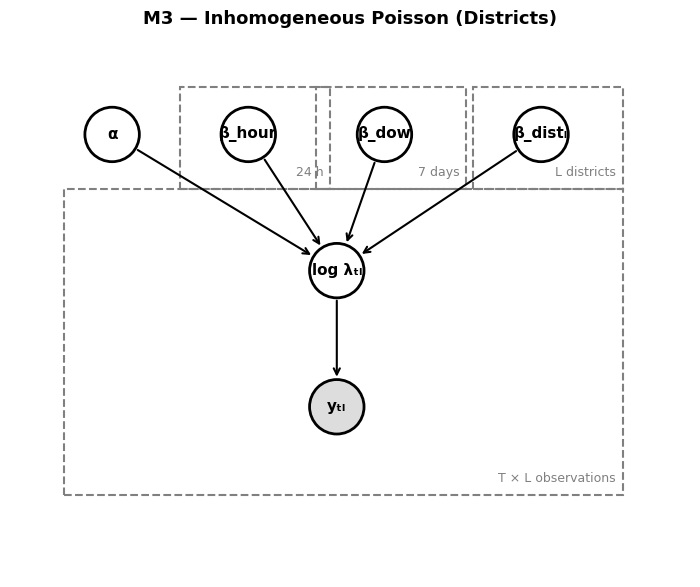

In [16]:
fig, fig_ax = plt.subplots(figsize=(10, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.5,'y':6.5,'label':'α',        'obs':False},
           'b_hour':  {'x':3.5,'y':6.5,'label':'β_hour',   'obs':False},
           'b_dow':   {'x':5.5,'y':6.5,'label':'β_dow',    'obs':False},
           'b_dist':  {'x':7.8,'y':6.5,'label':'β_distₗ', 'obs':False},
           'log_lam': {'x':4.8,'y':4.5,'label':'log λₜₗ', 'obs':False},
           'y':       {'x':4.8,'y':2.5,'label':'yₜₗ',     'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('b_dist','log_lam'),('log_lam','y')],
    plates=[{'x':0.8,'y':1.2,'w':8.2,'h':4.5,'label':'T × L observations'},
            {'x':2.5,'y':5.7,'w':2.2,'h':1.5,'label':'24 h'},
            {'x':4.5,'y':5.7,'w':2.2,'h':1.5,'label':'7 days'},
            {'x':6.8,'y':5.7,'w':2.2,'h':1.5,'label':'L districts'}])
fig_ax.set_title('M3 — Inhomogeneous Poisson (Districts)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [17]:
def model_3(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    b_dist = pyro.sample("b_dist", dist.Normal(torch.zeros(N_D), torch.ones(N_D)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 3 defined.")

Model 3 defined.


In [18]:
print("Training M3 — larger dataset (~193k obs), may take a few minutes...")
guide_3, losses_3 = run_svi(
    model_3,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d),
    n_steps=2000, lr=0.01)

Training M3 — larger dataset (~193k obs), may take a few minutes...
  step    0   ELBO = -369,158
  step  500   ELBO = -303,962
  step 1000   ELBO = -303,807
  step 1500   ELBO = -303,790


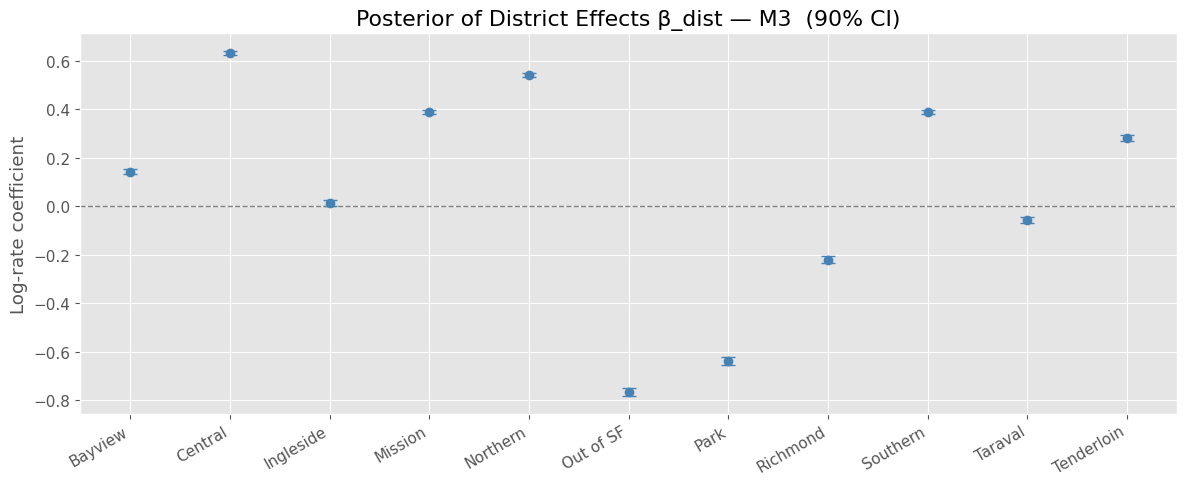

M3 Test → MAE: 1.097   RMSE: 1.478


In [19]:
samp_3 = Predictive(model_3, guide=guide_3, num_samples=1000,
                   return_sites=['b_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)

bd3 = samp_3['b_dist'].squeeze()
bd3_mean = bd3.mean(0).detach().numpy()
bd3_lo   = bd3.quantile(0.05, dim=0).detach().numpy()
bd3_hi   = bd3.quantile(0.95, dim=0).detach().numpy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(range(N_DISTRICTS), bd3_mean,
            yerr=[bd3_mean-bd3_lo, bd3_hi-bd3_mean],
            fmt='o', capsize=5, color='steelblue', lw=2)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks(range(N_DISTRICTS)); ax.set_xticklabels(districts, rotation=30, ha='right')
ax.set_ylabel('Log-rate coefficient')
ax.set_title('Posterior of District Effects β_dist — M3  (90% CI)')
plt.tight_layout(); plt.show()

y_pred_te_3 = Predictive(model_3, guide=guide_3, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS
)['y'].float().mean(0).detach().numpy()
mae3, rmse3 = metrics(counts_te_d.numpy(), y_pred_te_3)
print(f"M3 Test → MAE: {mae3:.3f}   RMSE: {rmse3:.3f}")

In [20]:
train_sf

,hour_bin,count,hour_of_day,day_of_week
0,2022-01-01 00:00:00,124,0,5
1,2022-01-01 01:00:00,27,1,5
2,2022-01-01 02:00:00,16,2,5
3,2022-01-01 03:00:00,9,3,5
4,2022-01-01 04:00:00,16,4,5
...,...,...,...,...
17515,2023-12-31 19:00:00,13,19,6
17516,2023-12-31 20:00:00,16,20,6
17517,2023-12-31 21:00:00,25,21,6
17518,2023-12-31 22:00:00,11,22,6


Model 3 other version

fixed step 0: loss=2.9784
fixed step 300: loss=2.2454
fixed step 600: loss=2.2454
fixed step 900: loss=2.2454
gp step    0 | loss=973231.562 | var=0.990 | ls=[1. 1.]
gp step  200 | loss=538956.000 | var=0.711 | ls=[0.62761307 0.81234384]
gp step  400 | loss=531225.000 | var=0.665 | ls=[0.53232497 0.710257  ]
gp step  600 | loss=526509.000 | var=0.615 | ls=[0.4847401  0.58731014]
gp step  800 | loss=522922.938 | var=0.562 | ls=[0.4766242  0.50189215]
gp step 1000 | loss=520870.375 | var=0.513 | ls=[0.46864945 0.47762233]
gp step 1200 | loss=519557.844 | var=0.464 | ls=[0.4631252  0.45716324]
gp step 1400 | loss=518606.250 | var=0.418 | ls=[0.45264667 0.44873178]
gp step 1600 | loss=517698.969 | var=0.374 | ls=[0.43160155 0.43494642]
gp step 1800 | loss=516876.656 | var=0.331 | ls=[0.41521078 0.41715834]
Train -> MAE: 3.638, RMSE: 4.730
Test  -> MAE: 5.062, RMSE: 6.646


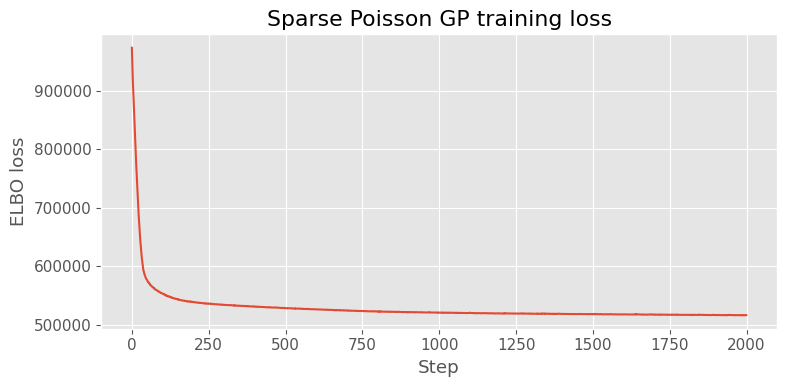

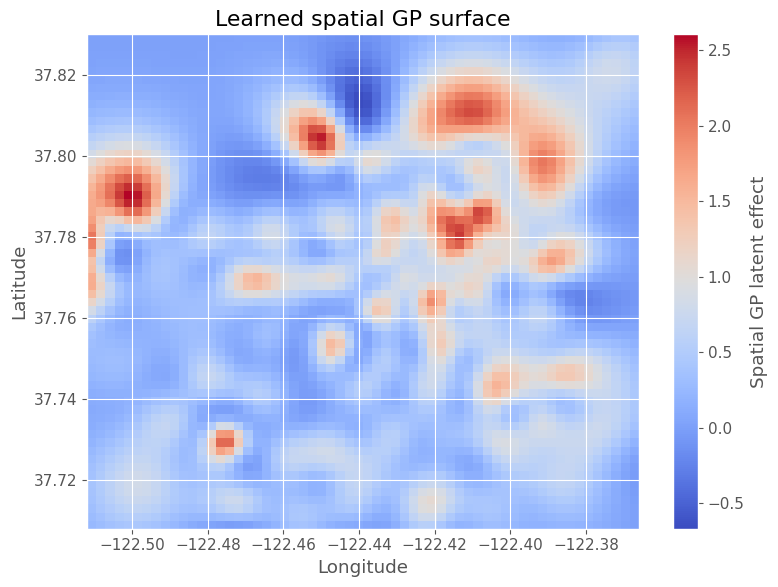

In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import pyro
import pyro.contrib.gp as gp
from pyro.infer import TraceMeanField_ELBO
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans

pyro.set_rng_seed(42)
pyro.clear_param_store()
torch.set_default_dtype(torch.float32)

# =========================================================
# 1. CLEAN FUNCTION
# =========================================================
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_map = {k: i for i, k in enumerate(dow_order)}
keep_types = ['Initial', 'Vehicle Initial', 'Coplogic Initial']

def prep_df(df_in):
    d = df_in.copy()

    d['Incident Datetime'] = pd.to_datetime(d['Incident Datetime'], errors='coerce')
    d = d.dropna(subset=['Incident Datetime', 'Incident Day of Week', 'Latitude', 'Longitude']).copy()

    if 'Report Type Description' in d.columns:
        d = d[d['Report Type Description'].isin(keep_types)].copy()

    d = d[d['Incident Day of Week'].isin(dow_map)].copy()
    d['hour'] = d['Incident Datetime'].dt.hour
    d['dow'] = d['Incident Day of Week'].map(dow_map).astype(int)

    d = d[
        d['Latitude'].between(37.70, 37.84) &
        d['Longitude'].between(-122.53, -122.35)
    ].copy()

    d['lat_r'] = d['Latitude'].round(3)
    d['lon_r'] = d['Longitude'].round(3)
    return d

train_d = prep_df(df_train)
test_d = prep_df(df_test)

# =========================================================
# 2. AGGREGATE TO COUNTS
# =========================================================
agg_tr = (
    train_d.groupby(['hour', 'dow', 'lat_r', 'lon_r'])
           .size()
           .reset_index(name='counts')
           .copy()
)

agg_te = (
    test_d.groupby(['hour', 'dow', 'lat_r', 'lon_r'])
          .size()
          .reset_index(name='counts')
          .copy()
)

# Standardize spatial coords using train stats
coord_mean = agg_tr[['lat_r', 'lon_r']].mean().values.astype(np.float32)
coord_std = agg_tr[['lat_r', 'lon_r']].std().values.astype(np.float32)

agg_tr['lat_s'] = (agg_tr['lat_r'] - coord_mean[0]) / coord_std[0]
agg_tr['lon_s'] = (agg_tr['lon_r'] - coord_mean[1]) / coord_std[1]

agg_te['lat_s'] = (agg_te['lat_r'] - coord_mean[0]) / coord_std[0]
agg_te['lon_s'] = (agg_te['lon_r'] - coord_mean[1]) / coord_std[1]

# =========================================================
# 3. DESIGN MATRICES
# =========================================================
def make_features(df_):
    hour_oh = np.eye(24, dtype=np.float32)[df_['hour'].values]
    dow_oh = np.eye(7, dtype=np.float32)[df_['dow'].values]
    X_fixed = np.concatenate([hour_oh, dow_oh], axis=1)
    X_spatial = df_[['lat_s', 'lon_s']].values.astype(np.float32)
    y = df_['counts'].values.astype(np.float32)
    return torch.tensor(X_fixed), torch.tensor(X_spatial), torch.tensor(y)

X_fixed_tr, X_spatial_tr, y_tr = make_features(agg_tr)
X_fixed_te, X_spatial_te, y_te = make_features(agg_te)

# =========================================================
# 4. FIXED EFFECTS OFFSET
# =========================================================
class FixedEffectsPoisson(torch.nn.Module):
    def __init__(self, p):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.tensor(0.0))
        self.beta = torch.nn.Parameter(torch.zeros(p))

    def forward(self, X):
        return self.alpha + X @ self.beta

fixed_model = FixedEffectsPoisson(X_fixed_tr.shape[1])
opt = torch.optim.Adam(fixed_model.parameters(), lr=0.03)

for step in range(1200):
    opt.zero_grad()
    eta = fixed_model(X_fixed_tr)
    loss = -torch.distributions.Poisson(rate=torch.exp(eta)).log_prob(y_tr).mean()
    loss.backward()
    opt.step()
    if step % 300 == 0:
        print(f"fixed step {step}: loss={loss.item():.4f}")

with torch.no_grad():
    offset_tr = fixed_model(X_fixed_tr).detach()
    offset_te = fixed_model(X_fixed_te).detach()

# =========================================================
# 5. INDUCING POINTS
# =========================================================
M = 150
kmeans = MiniBatchKMeans(n_clusters=M, random_state=42, batch_size=2048)
kmeans.fit(X_spatial_tr.numpy())
Xu = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

# =========================================================
# 6. SPARSE POISSON GP
# =========================================================
pyro.clear_param_store()

kernel = gp.kernels.Matern52(
    input_dim=2,
    variance=torch.tensor(1.0),
    lengthscale=torch.tensor([1.0, 1.0]),
)

likelihood = gp.likelihoods.Poisson()

vsgp = gp.models.VariationalSparseGP(
    X=X_spatial_tr,
    y=y_tr,
    kernel=kernel,
    Xu=Xu,
    likelihood=likelihood,
    whiten=True,
    jitter=1e-5,
    num_data=len(X_spatial_tr),
)

optimizer = torch.optim.Adam(vsgp.parameters(), lr=0.01)
loss_fn = TraceMeanField_ELBO().differentiable_loss

losses = []
for step in range(2000):
    optimizer.zero_grad()
    loss = loss_fn(vsgp.model, vsgp.guide)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if step % 200 == 0:
        print(
            f"gp step {step:4d} | loss={loss.item():.3f} | "
            f"var={vsgp.kernel.variance.item():.3f} | "
            f"ls={vsgp.kernel.lengthscale.detach().cpu().numpy()}"
        )

# =========================================================
# 7. PREDICTIONS
# =========================================================
with torch.no_grad():
    f_tr, _ = vsgp(X_spatial_tr, full_cov=False)
    f_te, _ = vsgp(X_spatial_te, full_cov=False)

rate_tr = torch.exp(offset_tr + f_tr)
rate_te = torch.exp(offset_te + f_te)

y_pred_tr = rate_tr.cpu().numpy()
y_pred_te = rate_te.cpu().numpy()

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

mae_tr, rmse_tr = metrics(y_tr.numpy(), y_pred_tr)
mae_te, rmse_te = metrics(y_te.numpy(), y_pred_te)

print(f"Train -> MAE: {mae_tr:.3f}, RMSE: {rmse_tr:.3f}")
print(f"Test  -> MAE: {mae_te:.3f}, RMSE: {rmse_te:.3f}")

# =========================================================
# 8. LOSS PLOT
# =========================================================
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Sparse Poisson GP training loss")
plt.xlabel("Step")
plt.ylabel("ELBO loss")
plt.tight_layout()
plt.show()

# =========================================================
# 9. SPATIAL SURFACE PLOT
# =========================================================
lat_grid = np.linspace(agg_tr['lat_r'].min(), agg_tr['lat_r'].max(), 60)
lon_grid = np.linspace(agg_tr['lon_r'].min(), agg_tr['lon_r'].max(), 60)

grid = np.array([(la, lo) for la in lat_grid for lo in lon_grid], dtype=np.float32)
grid_s = np.column_stack([
    (grid[:, 0] - coord_mean[0]) / coord_std[0],
    (grid[:, 1] - coord_mean[1]) / coord_std[1],
]).astype(np.float32)

X_grid = torch.tensor(grid_s)

with torch.no_grad():
    f_grid, _ = vsgp(X_grid, full_cov=False)

f_grid = f_grid.cpu().numpy().reshape(len(lat_grid), len(lon_grid))

plt.figure(figsize=(8, 6))
plt.imshow(
    f_grid,
    origin='lower',
    aspect='auto',
    extent=[lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
    cmap='coolwarm'
)
plt.colorbar(label='Spatial GP latent effect')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Learned spatial GP surface')
plt.tight_layout()
plt.show()

Model 3 - Grid cell solution

step    0  loss = 1629504.69
step  200  loss = 163768.62
step  400  loss = 131801.64
step  600  loss = 131031.55
step  800  loss = 130592.62
step 1000  loss = 130635.38
step 1200  loss = 129908.79
step 1400  loss = 129607.44
step 1600  loss = 129966.91
step 1800  loss = 129585.16
Grid model TEST  -> MAE: 13.863   RMSE: 24.136
Grid model TRAIN -> MAE: 4.487   RMSE: 8.875


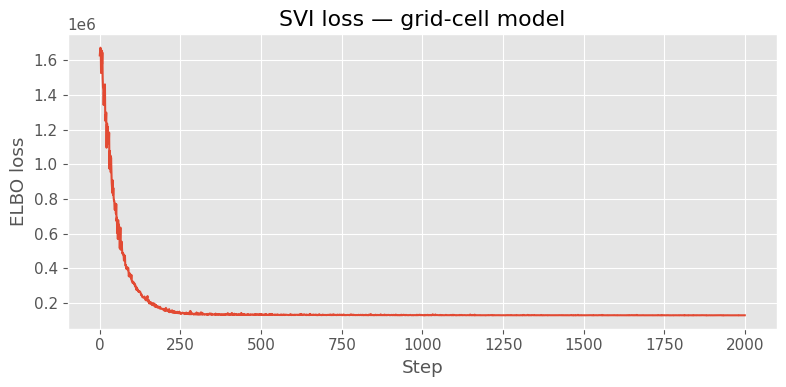

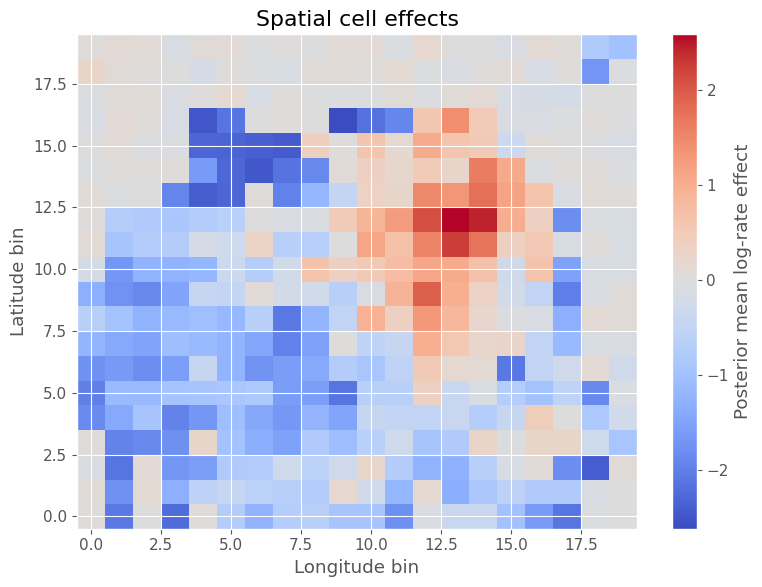

In [25]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
import pyro.optim as optim
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
pyro.clear_param_store()

# list of columns you need
use_cols = [
    'Incident Datetime', 'Incident Day of Week',
    'Latitude', 'Longitude', 'Police District',
    'Report Type Description'
]

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_map = {k: i for i, k in enumerate(dow_order)}
keep_types = ['Initial', 'Vehicle Initial', 'Coplogic Initial']

def prep_df(df_in):
    d = df_in.copy()
    d['Incident Datetime'] = pd.to_datetime(d['Incident Datetime'], errors='coerce')
    d = d.dropna(subset=['Incident Datetime', 'Incident Day of Week', 'Latitude', 'Longitude']).copy()

    if 'Report Type Description' in d.columns:
        d = d[d['Report Type Description'].isin(keep_types)].copy()

    d = d[d['Incident Day of Week'].isin(dow_map)].copy()
    d['hour'] = d['Incident Datetime'].dt.hour
    d['dow'] = d['Incident Day of Week'].map(dow_map).astype(int)

    # SF bounds
    d = d[
        d['Latitude'].between(37.70, 37.84) &
        d['Longitude'].between(-122.53, -122.35)
    ].copy()

    return d

train_clean = prep_df(df_train)
test_clean  = prep_df(df_test)

# spatial grid (same for both)
N_LAT_BINS = 20
N_LON_BINS = 20

lat_min = min(train_clean['Latitude'].min(), test_clean['Latitude'].min())
lat_max = max(train_clean['Latitude'].max(), test_clean['Latitude'].max())
lon_min = min(train_clean['Longitude'].min(), test_clean['Longitude'].min())
lon_max = max(train_clean['Longitude'].max(), test_clean['Longitude'].max())

lat_edges = np.linspace(lat_min, lat_max, N_LAT_BINS + 1)
lon_edges = np.linspace(lon_min, lon_max, N_LON_BINS + 1)

def add_cell(df_):
    df_['lat_bin'] = np.clip(np.digitize(df_['Latitude'], lat_edges) - 1, 0, N_LAT_BINS - 1)
    df_['lon_bin'] = np.clip(np.digitize(df_['Longitude'], lon_edges) - 1, 0, N_LON_BINS - 1)
    df_['cell_id'] = df_['lat_bin'] * N_LON_BINS + df_['lon_bin']
    return df_

train_clean = add_cell(train_clean)
test_clean  = add_cell(test_clean)

# aggregate counts
agg_train = (
    train_clean.groupby(['hour', 'dow', 'cell_id'])
              .size()
              .reset_index(name='counts')
              .copy()
)
agg_test = (
    test_clean.groupby(['hour', 'dow', 'cell_id'])
             .size()
             .reset_index(name='counts')
             .copy()
)

# get cell centers for plotting
cell_lookup = (
    train_clean.groupby('cell_id')[['Latitude', 'Longitude']]
               .mean()
               .reset_index()
               .rename(columns={'Latitude': 'cell_lat', 'Longitude': 'cell_lon'})
)
N_CELLS = N_LAT_BINS * N_LON_BINS


hour_tr = torch.tensor(agg_train['hour'].values, dtype=torch.long)
dow_tr  = torch.tensor(agg_train['dow'].values,  dtype=torch.long)
cell_tr = torch.tensor(agg_train['cell_id'].values, dtype=torch.long)
counts_tr = torch.tensor(agg_train['counts'].values, dtype=torch.float)

hour_te = torch.tensor(agg_test['hour'].values, dtype=torch.long)
dow_te  = torch.tensor(agg_test['dow'].values,  dtype=torch.long)
cell_te = torch.tensor(agg_test['cell_id'].values, dtype=torch.long)
counts_te = torch.tensor(agg_test['counts'].values, dtype=torch.float)


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

def model_grid(hour_idx, dow_idx, cell_idx, N_C, counts=None):
    alpha  = pyro.sample("alpha", dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    b_cell = pyro.sample("b_cell", dist.Normal(torch.zeros(N_C), torch.ones(N_C)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_cell[cell_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

guide_grid = AutoNormal(model_grid)
optimizer = optim.Adam({"lr": 0.01})
svi = SVI(model_grid, guide_grid, optimizer, loss=Trace_ELBO())

losses = []
n_steps = 2000
for step in range(n_steps):
    loss = svi.step(hour_tr, dow_tr, cell_tr, N_CELLS, counts_tr)
    losses.append(loss)
    if step % 200 == 0:
        print(f"step {step:4d}  loss = {loss:.2f}")




# 5.1 Test predictions
pred_test = Predictive(model_grid, guide=guide_grid, num_samples=100, return_sites=['y'])
pred_y_te = pred_test(hour_te, dow_te, cell_te, N_CELLS)['y'].float().mean(0).detach().cpu().numpy()
mae_te, rmse_te = metrics(counts_te.numpy(), pred_y_te)

print(f"Grid model TEST  -> MAE: {mae_te:.3f}   RMSE: {rmse_te:.3f}")

# 5.2 Train predictions
pred_train = Predictive(model_grid, guide=guide_grid, num_samples=100, return_sites=['y'])
pred_y_tr = pred_train(hour_tr, dow_tr, cell_tr, N_CELLS)['y'].float().mean(0).detach().cpu().numpy()
mae_tr, rmse_tr = metrics(counts_tr.numpy(), pred_y_tr)

print(f"Grid model TRAIN -> MAE: {mae_tr:.3f}   RMSE: {rmse_tr:.3f}")

# 6.1 loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("SVI loss — grid-cell model")
plt.xlabel("Step")
plt.ylabel("ELBO loss")
plt.tight_layout()
plt.show()

# 6.2 heatmap
grid_mat = np.full((N_LAT_BINS, N_LON_BINS), np.nan)

samp_3 = Predictive(model_grid, guide=guide_grid, num_samples=1000, return_sites=['b_cell'])(
    hour_tr, dow_tr, cell_tr, N_CELLS
)

bd3 = samp_3['b_cell'].squeeze()
bd3_mean = bd3.mean(0).detach().numpy()
for cid in range(N_CELLS):
    r = cid // N_LON_BINS
    c = cid % N_LON_BINS
    grid_mat[r, c] = bd3_mean[cid]

plt.figure(figsize=(8, 6))
plt.imshow(grid_mat, origin='lower', aspect='auto', cmap='coolwarm')
plt.colorbar(label='Posterior mean log-rate effect')
plt.title('Spatial cell effects')
plt.xlabel('Longitude bin')
plt.ylabel('Latitude bin')
plt.tight_layout()
plt.show()

## 7. Model 4 — Hierarchical Poisson Process (Partial Pooling)

District effects now share a **common prior** with learned mean and variance. This is the key difference from M3: instead of independent $\mathcal{N}(0,1)$ priors, districts are drawn from a group distribution that is itself inferred from data.

### Generative Process

$$\mu_{\text{dist}} \sim \mathcal{N}(0,1), \quad \sigma_{\text{dist}} \sim \text{HalfNormal}(1)$$
$$\beta^{\text{dist}}_\ell \sim \mathcal{N}(\mu_{\text{dist}},\; \sigma_{\text{dist}}), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \beta^{\text{dist}}_\ell$$
$$y_{t\ell} \sim \text{Poisson}(\exp(\log\lambda_{t\ell}))$$

**Partial pooling** shrinks district estimates toward the group mean, reducing posterior uncertainty — especially useful for low-activity districts with few observations.

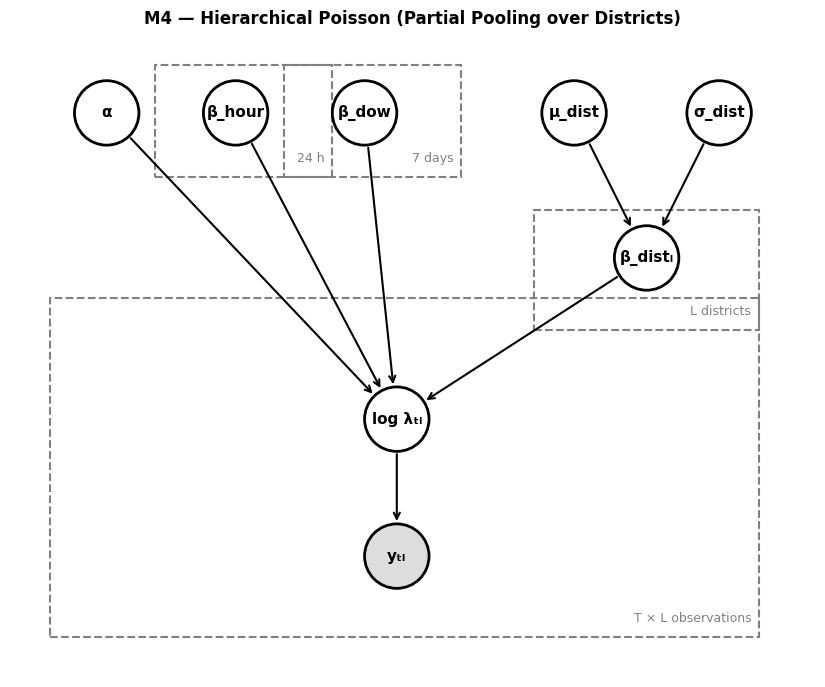

In [22]:
fig, fig_ax = plt.subplots(figsize=(10, 7))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.2,'y':7.0,'label':'α',         'obs':False},
           'b_hour':  {'x':2.8,'y':7.0,'label':'β_hour',    'obs':False},
           'b_dow':   {'x':4.4,'y':7.0,'label':'β_dow',     'obs':False},
           'mu_d':    {'x':7.0,'y':7.0,'label':'μ_dist',    'obs':False},
           'sig_d':   {'x':8.8,'y':7.0,'label':'σ_dist',    'obs':False},
           'b_dist':  {'x':7.9,'y':5.2,'label':'β_distₗ',  'obs':False},
           'log_lam': {'x':4.8,'y':3.2,'label':'log λₜₗ',  'obs':False},
           'y':       {'x':4.8,'y':1.5,'label':'yₜₗ',      'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('mu_d','b_dist'),('sig_d','b_dist'),('b_dist','log_lam'),('log_lam','y')],
    plates=[{'x':0.5,'y':0.5,'w':8.8,'h':4.2,'label':'T × L observations'},
            {'x':6.5,'y':4.3,'w':2.8,'h':1.5,'label':'L districts'},
            {'x':1.8,'y':6.2,'w':2.2,'h':1.4,'label':'24 h'},
            {'x':3.4,'y':6.2,'w':2.2,'h':1.4,'label':'7 days'}])
fig_ax.set_title('M4 — Hierarchical Poisson (Partial Pooling over Districts)',
                 fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [23]:
def model_4(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    mu_d   = pyro.sample("mu_dist",    dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))
    b_dist = pyro.sample("b_dist",
                         dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 4 defined.")

Model 4 defined.


In [33]:
# --- 1. Train M4 first ---
pyro.clear_param_store()

def model_4(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    mu_d   = pyro.sample("mu_dist",    dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))
    b_dist = pyro.sample("b_dist",
                         dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

guide_4 = AutoNormal(model_4)
optimizer = optim.Adam({"lr": 0.01})
svi     = SVI(model_4, guide_4, optimizer, loss=Trace_ELBO())

losses_4 = []
n_steps = 2000
for step in range(n_steps):
    loss = svi.step(hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)
    losses_4.append(loss)
    if step % 200 == 0:
        print(f"step {step:4d}  loss = {loss:.2f}")

step    0  loss = 3373029.14
step  200  loss = 47766.10
step  400  loss = 23052.41
step  600  loss = 20215.05
step  800  loss = 18163.64
step 1000  loss = 17601.89
step 1200  loss = 17409.10
step 1400  loss = 17277.54
step 1600  loss = 16883.69
step 1800  loss = 18255.00


ValueError: operands could not be broadcast together with shapes (400,) (11,) 

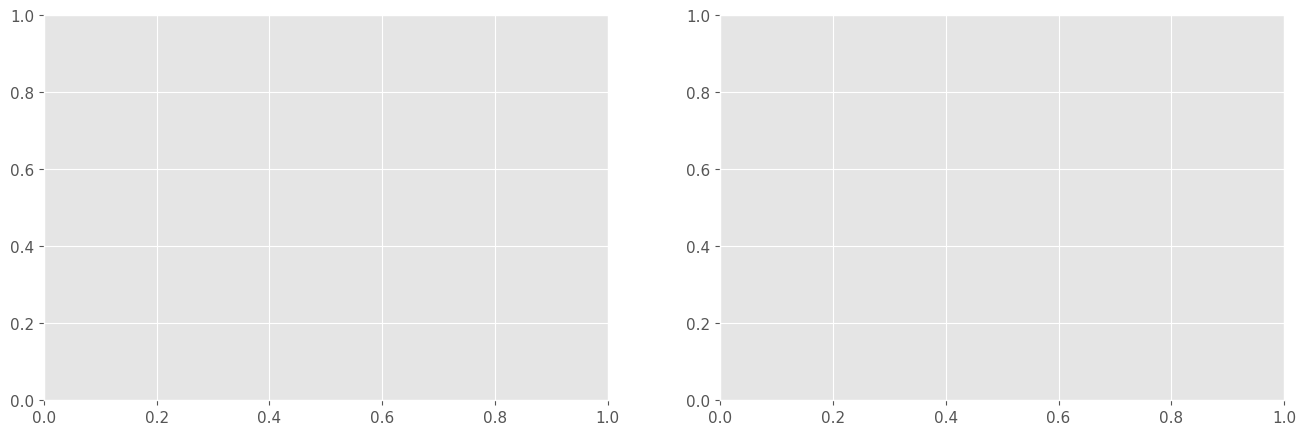

In [34]:
# --- 2. Now analyze posterior (this block can now run) ---
samp_4 = Predictive(model_4, guide=guide_4, num_samples=1000,
                   return_sites=['b_dist','mu_dist','sigma_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)

bd4 = samp_4['b_dist'].squeeze()
bd4_mean = bd4.mean(0).detach().numpy()
bd4_lo   = bd4.quantile(0.05, dim=0).detach().numpy()
bd4_hi   = bd4.quantile(0.95, dim=0).detach().numpy()

# M3 vs M4 partial pooling comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_, mn, lo, hi, title in zip(
        axes,
        [bd3_mean, bd4_mean], [bd3_lo, bd4_lo], [bd3_hi, bd4_hi],
        ['M3 — Independent priors (no pooling)',
         'M4 — Hierarchical prior (partial pooling)']):
    ax_.errorbar(range(N_DISTRICTS), mn, yerr=[mn-lo, hi-mn],
                 fmt='o', capsize=5, color='steelblue', lw=2)
    ax_.axhline(0, color='gray', ls='--', lw=1)
    ax_.set_xticks(range(N_DISTRICTS))
    ax_.set_xticklabels(districts, rotation=30, ha='right')
    ax_.set_ylabel('Log-rate coefficient')
    ax_.set_title(f'{title}\nMean 90% CI width: {(hi-lo).mean():.3f}')
plt.suptitle('Partial Pooling Effect: M3 vs M4', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


# --- 3. Test prediction with the same trained guide ---
y_pred_te_4 = Predictive(model_4, guide=guide_4, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS
)['y'].float().mean(0).detach().numpy()
mae4, rmse4 = metrics(counts_te_d.numpy(), y_pred_te_4)
print(f"M4 Test → MAE: {mae4:.3f}   RMSE: {rmse4:.3f}")
print(f"σ_dist posterior mean: {samp_4['sigma_dist'].mean().item():.3f}")

Model 4 - Hierarchical - version 2

Training hierarchical district model...
step    0 | loss = 3300943.94
step  200 | loss = 47607.54
step  400 | loss = 24763.63
step  600 | loss = 22412.53
step  800 | loss = 18729.42
step 1000 | loss = 17300.96
step 1200 | loss = 19184.75
step 1400 | loss = 18019.97
step 1600 | loss = 17249.92
step 1800 | loss = 17180.45
M4-district TRAIN -> MAE: 42.415 | RMSE: 62.942
M4-district TEST  -> MAE: 261.523 | RMSE: 309.555
M4-district sigma posterior mean: 0.809

Training hierarchical cell model...
step    0 | loss = 1621577.59
step  200 | loss = 157361.60
step  400 | loss = 133461.66
step  600 | loss = 138839.37
step  800 | loss = 131773.28
step 1000 | loss = 131175.47
step 1200 | loss = 130232.31
step 1400 | loss = 129945.17
step 1600 | loss = 129380.88
step 1800 | loss = 129435.29
M4-cell TRAIN -> MAE: 4.498 | RMSE: 8.880
M4-cell TEST  -> MAE: 14.110 | RMSE: 24.621
M4-cell sigma posterior mean: 1.040

Comparison table:
                      Model  Train MAE  Train RMSE   Test MAE   Test RM

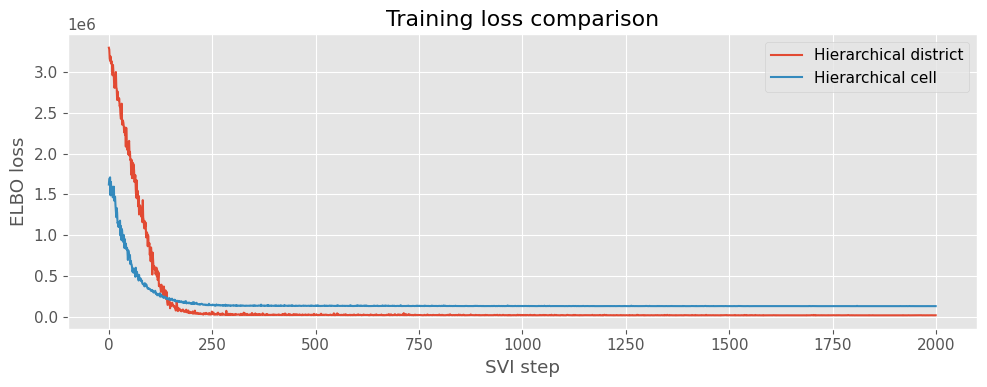

In [28]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
import pyro.optim as optim
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)

# --------------------------------------------------
# 1. Common setup
# --------------------------------------------------
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_map = {k: i for i, k in enumerate(dow_order)}
keep_types = ['Initial', 'Vehicle Initial', 'Coplogic Initial']

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

def prep_df(df_in):
    d = df_in.copy()

    d['Incident Datetime'] = pd.to_datetime(d['Incident Datetime'], errors='coerce')
    d = d.dropna(subset=['Incident Datetime', 'Incident Day of Week', 'Latitude', 'Longitude']).copy()

    if 'Report Type Description' in d.columns:
        d = d[d['Report Type Description'].isin(keep_types)].copy()

    d = d[d['Incident Day of Week'].isin(dow_map)].copy()
    d['hour'] = d['Incident Datetime'].dt.hour
    d['dow'] = d['Incident Day of Week'].map(dow_map).astype(int)

    d = d[
        d['Latitude'].between(37.70, 37.84) &
        d['Longitude'].between(-122.53, -122.35)
    ].copy()

    return d

train_clean = prep_df(df_train)
test_clean  = prep_df(df_test)

# --------------------------------------------------
# 2. District-based aggregated data
# --------------------------------------------------
all_districts = sorted(
    pd.concat([
        train_clean['Police District'].dropna(),
        test_clean['Police District'].dropna()
    ]).unique()
)
district_to_id = {d:i for i, d in enumerate(all_districts)}
N_DISTRICTS = len(all_districts)
districts = all_districts

train_clean = train_clean.dropna(subset=['Police District']).copy()
test_clean  = test_clean.dropna(subset=['Police District']).copy()

train_clean['dist_id'] = train_clean['Police District'].map(district_to_id)
test_clean['dist_id']  = test_clean['Police District'].map(district_to_id)

agg_train_d = (
    train_clean.groupby(['hour', 'dow', 'dist_id'])
               .size()
               .reset_index(name='counts')
               .copy()
)

agg_test_d = (
    test_clean.groupby(['hour', 'dow', 'dist_id'])
              .size()
              .reset_index(name='counts')
              .copy()
)

hour_tr_d   = torch.tensor(agg_train_d['hour'].values, dtype=torch.long)
dow_tr_d    = torch.tensor(agg_train_d['dow'].values, dtype=torch.long)
distid_tr_d = torch.tensor(agg_train_d['dist_id'].values, dtype=torch.long)
counts_tr_d = torch.tensor(agg_train_d['counts'].values, dtype=torch.float)

hour_te_d   = torch.tensor(agg_test_d['hour'].values, dtype=torch.long)
dow_te_d    = torch.tensor(agg_test_d['dow'].values, dtype=torch.long)
distid_te_d = torch.tensor(agg_test_d['dist_id'].values, dtype=torch.long)
counts_te_d = torch.tensor(agg_test_d['counts'].values, dtype=torch.float)

# --------------------------------------------------
# 3. Cell/location-based aggregated data
# --------------------------------------------------
N_LAT_BINS = 20
N_LON_BINS = 20

lat_min = min(train_clean['Latitude'].min(), test_clean['Latitude'].min())
lat_max = max(train_clean['Latitude'].max(), test_clean['Latitude'].max())
lon_min = min(train_clean['Longitude'].min(), test_clean['Longitude'].min())
lon_max = max(train_clean['Longitude'].max(), test_clean['Longitude'].max())

lat_edges = np.linspace(lat_min, lat_max, N_LAT_BINS + 1)
lon_edges = np.linspace(lon_min, lon_max, N_LON_BINS + 1)

def add_cell_ids(df_):
    out = df_.copy()
    out['lat_bin'] = np.clip(np.digitize(out['Latitude'], lat_edges) - 1, 0, N_LAT_BINS - 1)
    out['lon_bin'] = np.clip(np.digitize(out['Longitude'], lon_edges) - 1, 0, N_LON_BINS - 1)
    out['cell_id'] = out['lat_bin'] * N_LON_BINS + out['lon_bin']
    return out

train_cell = add_cell_ids(train_clean)
test_cell  = add_cell_ids(test_clean)

N_CELLS = N_LAT_BINS * N_LON_BINS

agg_train_c = (
    train_cell.groupby(['hour', 'dow', 'cell_id'])
              .size()
              .reset_index(name='counts')
              .copy()
)

agg_test_c = (
    test_cell.groupby(['hour', 'dow', 'cell_id'])
             .size()
             .reset_index(name='counts')
             .copy()
)

hour_tr_c   = torch.tensor(agg_train_c['hour'].values, dtype=torch.long)
dow_tr_c    = torch.tensor(agg_train_c['dow'].values, dtype=torch.long)
cellid_tr_c = torch.tensor(agg_train_c['cell_id'].values, dtype=torch.long)
counts_tr_c = torch.tensor(agg_train_c['counts'].values, dtype=torch.float)

hour_te_c   = torch.tensor(agg_test_c['hour'].values, dtype=torch.long)
dow_te_c    = torch.tensor(agg_test_c['dow'].values, dtype=torch.long)
cellid_te_c = torch.tensor(agg_test_c['cell_id'].values, dtype=torch.long)
counts_te_c = torch.tensor(agg_test_c['counts'].values, dtype=torch.float)

# --------------------------------------------------
# 4. Hierarchical models
# --------------------------------------------------
def model_4_dist(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)

    alpha  = pyro.sample("alpha", dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow", dist.Normal(torch.zeros(7), torch.ones(7)).to_event(1))

    mu_d   = pyro.sample("mu_dist", dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))

    b_dist = pyro.sample(
        "b_dist",
        dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1)
    )

    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]

    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)


def model_4_cell(hour_idx, dow_idx, cell_idx, N_C, counts=None):
    N_C = int(N_C)

    alpha  = pyro.sample("alpha", dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow", dist.Normal(torch.zeros(7), torch.ones(7)).to_event(1))

    mu_c   = pyro.sample("mu_cell", dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_c  = pyro.sample("sigma_cell", dist.HalfNormal(torch.tensor(1.)))

    b_cell = pyro.sample(
        "b_cell",
        dist.Normal(torch.zeros(N_C) + mu_c, torch.zeros(N_C) + sig_c).to_event(1)
    )

    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_cell[cell_idx]

    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

# --------------------------------------------------
# 5. Fitting helper
# --------------------------------------------------
def fit_svi(model, args, n_steps=2000, lr=0.01):
    pyro.clear_param_store()
    guide = AutoNormal(model)
    optimizer = optim.Adam({"lr": lr})
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    losses = []
    for step in range(n_steps):
        loss = svi.step(*args)
        losses.append(loss)
        if step % 200 == 0:
            print(f"step {step:4d} | loss = {loss:.2f}")
    return guide, losses

def posterior_mean_y(model, guide, pred_args, num_samples=200):
    pred = Predictive(model, guide=guide, num_samples=num_samples, return_sites=["y"])
    y_samps = pred(*pred_args)["y"].float()
    return y_samps.mean(0).detach().cpu().numpy()

# --------------------------------------------------
# 6. Fit district model
# --------------------------------------------------
print("Training hierarchical district model...")
guide_4_dist, losses_4_dist = fit_svi(
    model_4_dist,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d),
    n_steps=2000,
    lr=0.01
)

y_pred_tr_4_dist = posterior_mean_y(
    model_4_dist, guide_4_dist,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS),
    num_samples=200
)
mae_tr_4_dist, rmse_tr_4_dist = metrics(counts_tr_d.numpy(), y_pred_tr_4_dist)

y_pred_te_4_dist = posterior_mean_y(
    model_4_dist, guide_4_dist,
    (hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS),
    num_samples=200
)
mae_te_4_dist, rmse_te_4_dist = metrics(counts_te_d.numpy(), y_pred_te_4_dist)

print(f"M4-district TRAIN -> MAE: {mae_tr_4_dist:.3f} | RMSE: {rmse_tr_4_dist:.3f}")
print(f"M4-district TEST  -> MAE: {mae_te_4_dist:.3f} | RMSE: {rmse_te_4_dist:.3f}")

samp_4_dist = Predictive(
    model_4_dist, guide=guide_4_dist, num_samples=1000,
    return_sites=["b_dist", "mu_dist", "sigma_dist"]
)(
    hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d
)

print(f"M4-district sigma posterior mean: {samp_4_dist['sigma_dist'].mean().item():.3f}")

# --------------------------------------------------
# 7. Fit cell model
# --------------------------------------------------
print("\nTraining hierarchical cell model...")
guide_4_cell, losses_4_cell = fit_svi(
    model_4_cell,
    (hour_tr_c, dow_tr_c, cellid_tr_c, N_CELLS, counts_tr_c),
    n_steps=2000,
    lr=0.01
)

y_pred_tr_4_cell = posterior_mean_y(
    model_4_cell, guide_4_cell,
    (hour_tr_c, dow_tr_c, cellid_tr_c, N_CELLS),
    num_samples=200
)
mae_tr_4_cell, rmse_tr_4_cell = metrics(counts_tr_c.numpy(), y_pred_tr_4_cell)

y_pred_te_4_cell = posterior_mean_y(
    model_4_cell, guide_4_cell,
    (hour_te_c, dow_te_c, cellid_te_c, N_CELLS),
    num_samples=200
)
mae_te_4_cell, rmse_te_4_cell = metrics(counts_te_c.numpy(), y_pred_te_4_cell)

print(f"M4-cell TRAIN -> MAE: {mae_tr_4_cell:.3f} | RMSE: {rmse_tr_4_cell:.3f}")
print(f"M4-cell TEST  -> MAE: {mae_te_4_cell:.3f} | RMSE: {rmse_te_4_cell:.3f}")

samp_4_cell = Predictive(
    model_4_cell, guide=guide_4_cell, num_samples=1000,
    return_sites=["b_cell", "mu_cell", "sigma_cell"]
)(
    hour_tr_c, dow_tr_c, cellid_tr_c, N_CELLS, counts_tr_c
)

print(f"M4-cell sigma posterior mean: {samp_4_cell['sigma_cell'].mean().item():.3f}")

# --------------------------------------------------
# 8. Results table
# --------------------------------------------------
results = pd.DataFrame({
    "Model": [
        "M4 hierarchical district",
        "M4 hierarchical cell"
    ],
    "Train MAE": [
        mae_tr_4_dist,
        mae_tr_4_cell
    ],
    "Train RMSE": [
        rmse_tr_4_dist,
        rmse_tr_4_cell
    ],
    "Test MAE": [
        mae_te_4_dist,
        mae_te_4_cell
    ],
    "Test RMSE": [
        rmse_te_4_dist,
        rmse_te_4_cell
    ],
    "Posterior pooling SD": [
        samp_4_dist["sigma_dist"].mean().item(),
        samp_4_cell["sigma_cell"].mean().item()
    ]
})

print("\nComparison table:")
print(results.round(3))

# --------------------------------------------------
# 9. Loss comparison plot
# --------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(losses_4_dist, label="Hierarchical district")
plt.plot(losses_4_cell, label="Hierarchical cell")
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training loss comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- 1. Train M4 first ---
pyro.clear_param_store()

def model_4(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    mu_d   = pyro.sample("mu_dist",    dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))
    b_dist = pyro.sample("b_dist",
                         dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

guide_4 = AutoNormal(model_4)
optimizer = optim.Adam({"lr": 0.01})
svi     = SVI(model_4, guide_4, optimizer, loss=Trace_ELBO())

losses_4 = []
n_steps = 2000
for step in range(n_steps):
    loss = svi.step(hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)
    losses_4.append(loss)
    if step % 200 == 0:
        print(f"step {step:4d}  loss = {loss:.2f}")

step    0  loss = 3313842.21
step  200  loss = 54120.41
step  400  loss = 21670.77
step  600  loss = 21117.28
step  800  loss = 18486.08
step 1000  loss = 20195.30
step 1200  loss = 17650.36
step 1400  loss = 18531.60
step 1600  loss = 17149.33


## 8. Model Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_1, lw=1.2, alpha=0.85, label='M1 — Homogeneous Poisson (SF-wide)')
ax.plot(losses_2, lw=1.2, alpha=0.85, label='M2 — + Time of Day (SF-wide)')
ax.plot(losses_3, lw=1.2, alpha=0.85, label='M3 — + Districts (per-district)')
ax.plot(losses_4, lw=1.2, alpha=0.85, label='M4 — Hierarchical (per-district)')
ax.set_xlabel('SVI step'); ax.set_ylabel('ELBO loss')
ax.set_title('SVI Convergence — All Models')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
from IPython.display import display

results = pd.DataFrame({
    'Model':  ['M1 Homogeneous','M2 + Time of Day','M3 + Districts','M4 Hierarchical'],
    'MAE':    [round(mae1,3), round(mae2,3), round(mae3,3), round(mae4,3)],
    'RMSE':   [round(rmse1,3), round(rmse2,3), round(rmse3,3), round(rmse4,3)],
})
print(results.to_string(index=False))

x = np.arange(len(results))
colors = ['#4878d0','#ee854a','#6acc65','#d65f5f']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_, metric in zip(axes, ['MAE','RMSE']):
    bars = ax_.bar(x, results[metric], color=colors, alpha=0.85, width=0.6)
    ax_.set_xticks(x)
    ax_.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=10)
    ax_.set_title(f'Test Set {metric}', fontsize=13)
    ax_.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax_.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
display(fig)
plt.close()


In [ ]:
# Posterior predictive check: M2 (SF-wide) and M4 (per-district)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_, guide_, model_, pred_args, y_true_tensor, title in [
    (axes[0], guide_2, model_2,
     (hour_te_sf, dow_te_sf),
     counts_te_sf, 'M2 — SF-wide'),
    (axes[1], guide_4, model_4,
     (hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS),
     counts_te_d, 'M4 — Per-district'),
]:
    y_pp = Predictive(model_, guide=guide_, num_samples=200,
                      return_sites=['y'])(*pred_args)['y'].float().mean(0).detach().numpy()
    y_true = y_true_tensor.numpy()
    ax_.hist(y_true, bins=30, alpha=0.6, density=True,
             color='black', histtype='step', lw=2, label='Observed')
    ax_.hist(y_pp,   bins=30, alpha=0.5, density=True,
             color='steelblue', label='Predicted')
    ax_.set_xlabel('Incident count'); ax_.set_ylabel('Density')
    ax_.set_title(f'Posterior Predictive Check — {title}')
    ax_.legend()
plt.tight_layout()
display(fig)
plt.close()


## 9. VI vs MCMC (NUTS) on Model 1

As in the course exercises, we compare our variational approximation to NUTS on the simplest model. If the posteriors agree, VI is validated as a reliable approximation.

In [ ]:
pyro.set_rng_seed(42)
nuts = NUTS(model_1, adapt_step_size=True)
mcmc = MCMC(nuts, num_samples=500, warmup_steps=200, disable_progbar=False)
mcmc.run(counts_tr_sf)
lam_mcmc = mcmc.get_samples()['lambda'].squeeze().detach().numpy()
print(f"MCMC done. Samples: {lam_mcmc.shape}")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lam_vi,   bins=50, alpha=0.5, density=True, color='steelblue',
        label=f'VI   (μ={lam_vi.mean():.2f}, σ={lam_vi.std():.3f})')
ax.hist(lam_mcmc, bins=50, alpha=0.5, density=True, color='darkorange',
        label=f'MCMC (μ={lam_mcmc.mean():.2f}, σ={lam_mcmc.std():.3f})')
ax.set_xlabel('λ (incidents/hour)'); ax.set_ylabel('Density')
ax.set_title('Posterior of λ — VI vs MCMC (M1)')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Discussion

### Summary

| Model | Key addition | Test data |
|---|---|---|
| M1 Homogeneous Poisson | Constant rate λ | SF-wide hourly |
| **M2 + Time of Day** | Hour + day-of-week effects | SF-wide hourly |
| M3 + Districts | Independent district effects | Per-district hourly |
| **M4 Hierarchical** | Partial pooling over districts | Per-district hourly |

### Key Findings

1. **Time of day matters (M1 → M2):** Hour-of-day posteriors show clear intra-day rhythm with afternoon/evening peaks. Adding these covariates substantially reduces test RMSE.

2. **Districts differ (M2 → M3):** District coefficients show large variation — Tenderloin, Mission, and Central are well above the citywide average.

3. **Partial pooling (M3 → M4):** The hierarchical prior narrows credible intervals, shrinking estimates toward the group mean. The inferred $\sigma_{\text{dist}}$ quantifies between-district heterogeneity.

4. **VI ≈ MCMC:** The `AutoDiagonalNormal` guide closely matches the NUTS posterior for M1, validating VI as a reliable and scalable approximation for all four models.

### Limitations & Extensions
- A **Hawkes process** could capture self-excitation (incidents triggering more incidents).
- A **GP prior** on $\lambda(t)$ would model smooth temporal trends without binning.
- Adding **crime category** as a covariate or as a separate model dimension.